In [1]:
import sys
sys.path.append("D:\Scunpair_Project\Diagonal-integration")
import mycode
import scanpy as sc
rna = sc.read_h5ad(r'D:\Scunpair_Project\Dataset\scRNA+scATAC 10x-Multiome-Pbmc10k\10x-Multiome-Pbmc10k-RNA.h5ad')
atac_gas = sc.read_h5ad(r'D:\Scunpair_Project\Dataset\scRNA+scATAC 10x-Multiome-Pbmc10k\10x-Multiome-Pbmc10k-FRAGS2RNA.h5ad')
atac_peak = sc.read_h5ad(r'D:\Scunpair_Project\Dataset\scRNA+scATAC 10x-Multiome-Pbmc10k\10x-Multiome-Pbmc10k-ATAC.h5ad')

In [2]:
rna.layers["counts"] = rna.X.copy()
atac_peak.layers["counts"] = atac_peak.X.copy()

# 取交集基因并对齐
cm_genes = sorted(list(set(atac_gas.var_names) & set(rna.var_names)))
rna = rna[:, cm_genes]
atac_gas = atac_gas[:, cm_genes]

# 计算高变基因
sc.pp.highly_variable_genes(rna, flavor='seurat_v3', n_top_genes=2000)
# sc.pp.highly_variable_genes(atac_gas, flavor='seurat_v3', n_top_genes=1000)

# 取共同的高变基因
shared_genes = rna.var_names[rna.var.highly_variable]
shared_genes = list(shared_genes)

rna = rna[:,shared_genes].copy()
atac_gas = atac_gas[:,shared_genes].copy()

sc.pp.normalize_total(rna)
sc.pp.log1p(rna)

sc.pp.normalize_total(atac_gas)
sc.pp.log1p(atac_gas)

sc.pp.scale(rna, max_value=10)
sc.pp.scale(atac_gas, max_value=10)



c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:174: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}
c:\Users\Administrator\miniconda3\envs\mycode\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
c:\Users\Administrator\miniconda3\envs\mycode\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [3]:
rna.obsm['link_feat'] = rna.X
atac_peak.obsm['link_feat'] = atac_gas.X

In [4]:
sc.pp.pca(rna, n_comps=30)
mycode.utils.lsi(atac_peak, n_components=100)

In [ ]:
atac_peak.obsm['X_lsi'] = mycode.utils.zscore_numpy(atac_peak.obsm['X_lsi'])
rna.obsm['X_pca'] = mycode.utils.zscore_numpy(rna.obsm['X_pca'])

In [ ]:
from scipy.spatial.distance import cdist
cost = cdist(rna.X, atac_gas.X, metric="correlation")

In [5]:
model_int = mycode.IntegrationModel(rna, atac_peak, batch_size=500, 
                           training_steps=10001, seed=1234, input_key = ["X_pca", "X_lsi"], celltype_col='cell_type',source_col=None,
                            n_latent=10, lambdaRecon = 10.0, lambdaLA = 10.0,
                            lambdaAlign = 5.0, lambdamGAN = 1.0, lambdabGAN = 0.0, lambdaGeo=1.0, lambdaCLIP=1.0, use_prior = False, model_path = r"D:\Scunpair_Project\Dataset\scRNA+scATAC 10x-Multiome-Pbmc10k")


In [6]:
model_int.train()
model_int.get_latent_representation()

Training started at: Thu Dec  4 22:47:57 2025
Step 0 | loss_Recon: 110.1692 | loss_LA: 5.9209 | loss_Align: 2.9237 | loss_Geo: 0.0000 | loss_CLIP: 0.0000 | loss_mGAN vs loss_mDis: -0.6691 vs 1.6764 | loss_bGAN vs loss_bDis: -0.0000 vs 0.0000
Step 1000 | loss_Recon: 5.6181 | loss_LA: 0.0181 | loss_Align: 0.8952 | loss_Geo: 0.0000 | loss_CLIP: 0.0000 | loss_mGAN vs loss_mDis: -1.3526 vs 1.3581 | loss_bGAN vs loss_bDis: -0.0000 vs 0.0000
Step 2000 | loss_Recon: 4.9942 | loss_LA: 0.0101 | loss_Align: 0.4979 | loss_Geo: 0.0000 | loss_CLIP: 0.0000 | loss_mGAN vs loss_mDis: -1.4403 vs 1.4465 | loss_bGAN vs loss_bDis: -0.0000 vs 0.0000
Step 3000 | loss_Recon: 5.0450 | loss_LA: 0.0077 | loss_Align: 0.4022 | loss_Geo: 0.0356 | loss_CLIP: 0.0000 | loss_mGAN vs loss_mDis: -1.3813 vs 1.3868 | loss_bGAN vs loss_bDis: -0.0000 vs 0.0000
Step 4000 | loss_Recon: 4.6089 | loss_LA: 0.0059 | loss_Align: 0.3076 | loss_Geo: 0.0237 | loss_CLIP: 0.0000 | loss_mGAN vs loss_mDis: -1.3770 vs 1.3818 | loss_bGAN vs

In [ ]:
atac_peak.layers['binary'] = atac_peak.X.copy()
atac_peak.layers['binary'][atac_peak.layers['binary']>0]=1

In [ ]:
model_imput = mycode.ImputationModel(rna, atac_peak, input_key = ['X_pca', 'X_lsi'], output_layer = ['counts', 'binary'], loss_type=['nb', 'bce'], batch_size = 128, 
                                     training_steps = 10001, lambdaRecon_x = 0.0, lambdaRecon_y = 10.0, lambdaLA = 0.0, model_path = r"D:\Scunpair_Project\Dataset\scRNA+scATAC 10x-Multiome-Pbmc10k")

D:\Scunpair_Project\Diagonal-integration\mycode\dataloader.py:75: UserWarning: Sparse data detected; converting to dense.
  warnings.warn("Sparse data detected; converting to dense.")


In [ ]:
model_imput.train()

✅ Loaded checkpoint from D:\Scunpair_Project\Dataset\scRNA+scATAC 10x-Multiome-Pbmc10k\ckpt.pth
Training started at: Thu Nov 13 22:52:24 2025
Step 0 | loss_Recon_x: 0.0000 | loss_LA: 0.0000 | loss_Recon_y: 80.6275 
Step 1000 | loss_Recon_x: 0.0000 | loss_LA: 0.0000 | loss_Recon_y: 71.5324 
Step 2000 | loss_Recon_x: 0.0000 | loss_LA: 0.0000 | loss_Recon_y: 71.4586 
Step 3000 | loss_Recon_x: 0.0000 | loss_LA: 0.0000 | loss_Recon_y: 71.3324 
Step 4000 | loss_Recon_x: 0.0000 | loss_LA: 0.0000 | loss_Recon_y: 71.2626 
Step 5000 | loss_Recon_x: 0.0000 | loss_LA: 0.0000 | loss_Recon_y: 71.3277 
Step 6000 | loss_Recon_x: 0.0000 | loss_LA: 0.0000 | loss_Recon_y: 71.5865 
Step 7000 | loss_Recon_x: 0.0000 | loss_LA: 0.0000 | loss_Recon_y: 71.4102 
Step 8000 | loss_Recon_x: 0.0000 | loss_LA: 0.0000 | loss_Recon_y: 71.3766 
Step 9000 | loss_Recon_x: 0.0000 | loss_LA: 0.0000 | loss_Recon_y: 71.2954 
Step 10000 | loss_Recon_x: 0.0000 | loss_LA: 0.0000 | loss_Recon_y: 71.2727 
Training finished. Time:

In [ ]:
del model_imput

In [ ]:
model_imput.get_latent_representation()

Started at: Thu Nov 13 22:55:15 2025
Completed at: Thu Nov 13 22:55:15 2025
Total time: 0.06 seconds
Processed 19262 samples
Latent space shape: (19262, 10)


In [7]:
import anndata as ad
import pandas as pd
adata_integrated = ad.AnnData(X=model_int.latent)
adata_integrated.obs = pd.concat([rna.obs, atac_gas.obs])
adata_integrated.obs['modality'] = ['RNA'] * rna.shape[0] + ['ATAC'] * atac_gas.shape[0]

In [8]:
sc.pp.neighbors(adata_integrated)
sc.tl.umap(adata_integrated)

c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


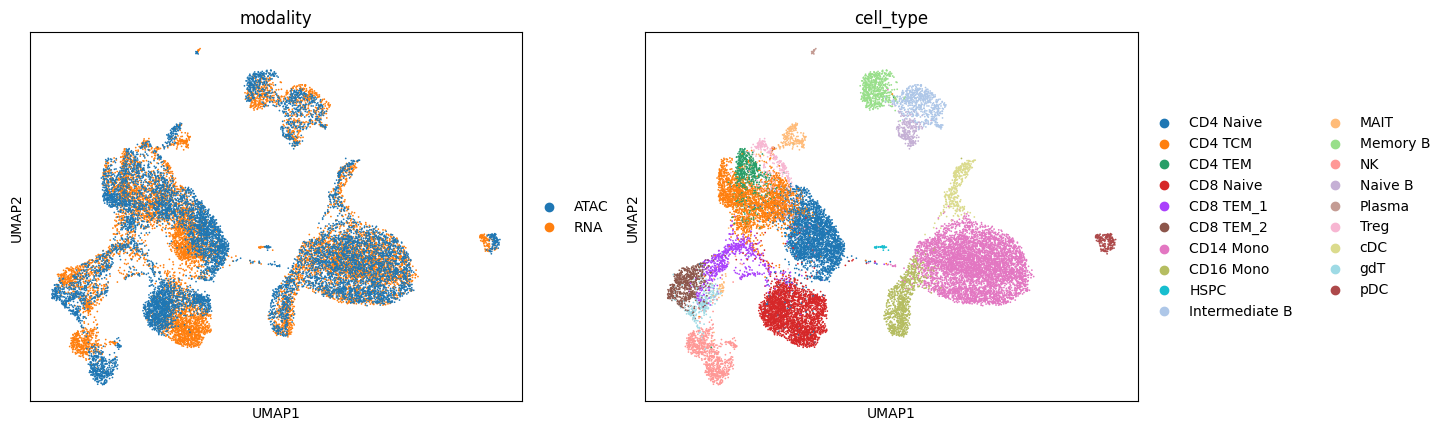

In [9]:
sc.pl.umap(adata_integrated, color=['modality','cell_type'])

In [10]:
import scib
adata_integrated.obsm["X_emb"] = adata_integrated.X
metrics = scib.metrics.metrics(
    adata_integrated,
    adata_integrated,
    batch_key='modality',
    label_key= 'cell_type',
    embed='X_emb',
    ari_=True,
    nmi_=True,
    silhouette_=True,
    graph_conn_= True,
    kBET_=False,
    isolated_labels_asw_=True,
    isolated_labels_f1_= True,
    lisi_graph_ = False
)

Recompute neighbors on rep X_emb instead of None
Cluster for cluster_0.2 with leiden


c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\scib\metrics\clustering.py:96: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  cluster_function(adata, resolution=res, key_added=resolution_key, **kwargs)


Cluster for cluster_0.4 with leiden
Cluster for cluster_0.6 with leiden
Cluster for cluster_0.8 with leiden
Cluster for cluster_1.0 with leiden
Cluster for cluster_1.2 with leiden
Cluster for cluster_1.4 with leiden
Cluster for cluster_1.6 with leiden
Cluster for cluster_1.8 with leiden
Cluster for cluster_2.0 with leiden
NMI...
ARI...
Silhouette score...
Isolated labels F1...
Isolated labels ASW...


c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\scib\metrics\isolated_labels.py:311: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_per_lab = tmp.groupby(label_key).agg({batch_key: "count"})
c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\scib\metrics\isolated_labels.py:186: UserWarning: iso_threshold is equal to number of batches in data, no isolated labels will be found
  isolated_labels = get_isolated_labels(
c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\scib\metrics\isolated_labels.py:311: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_per_lab = 

Graph connectivity...


c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\scib\metrics\graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\scib\metrics\graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\scib\metrics\graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\scib\metrics\graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use

In [11]:
metrics

,0
NMI_cluster/label,0.842956
ARI_cluster/label,0.832907
ASW_label,0.633223
ASW_label/batch,0.852876
PCR_batch,NaN
cell_cycle_conservation,NaN
isolated_label_F1,NaN
isolated_label_silhouette,NaN
graph_conn,0.993894
kBET,NaN


In [ ]:
model_imput.get_imputation()

Started at: Thu Nov 13 22:56:13 2025
Completed at: Thu Nov 13 22:56:16 2025
Total time: 2.99 seconds
Processed 19262 samples


In [ ]:
import anndata as ad
import pandas as pd
imputed_BtoA = model_imput.imputed_BtoA
imputed_df_BtoA = pd.DataFrame(imputed_BtoA, index=atac_peak.obs.index, columns=rna.var_names)
imputed_AtoB = model_imput.imputed_AtoB
imputed_df_AtoB = pd.DataFrame(imputed_AtoB, index=rna.obs.index, columns=atac_peak.var_names)

In [ ]:
sc.pp.neighbors(rna)
sc.tl.umap(rna)

In [ ]:
sc.pp.neighbors(atac_peak, use_rep='X_lsi')
sc.tl.umap(atac_peak)

In [ ]:
rna.obs['imputed_A2M'] = imputed_df_BtoA['A2M']
atac_peak.obs['imputed_A2M'] = imputed_df_BtoA['A2M']

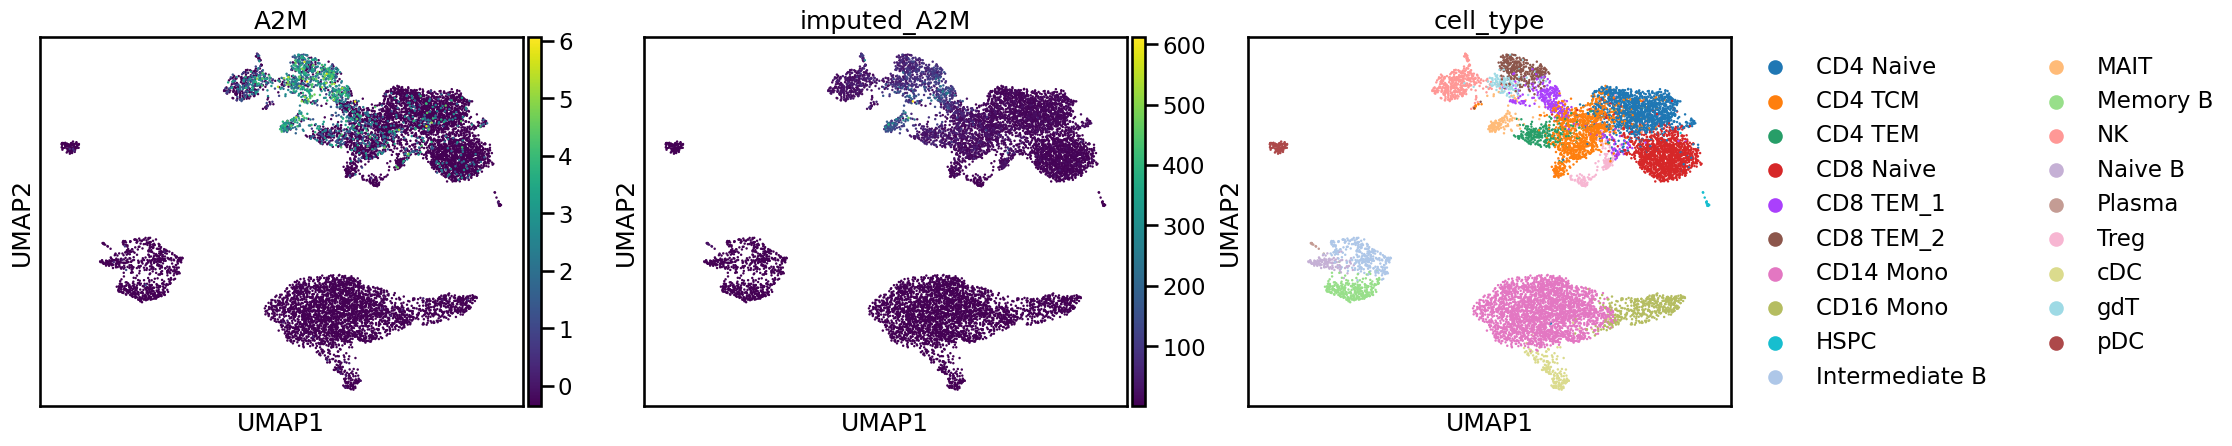

In [ ]:
sc.pl.umap(rna, color=['A2M', 'imputed_A2M', 'cell_type'])

In [ ]:
rna.obs['imputed_chr1:1016432-1028059'] = imputed_df_AtoB['chr1:1016432-1028059']
atac_peak.obs['imputed_chr1:1016432-1028059'] = imputed_df_AtoB['chr1:1016432-1028059']

In [ ]:
atac_peak.X=atac_peak.layers['counts']

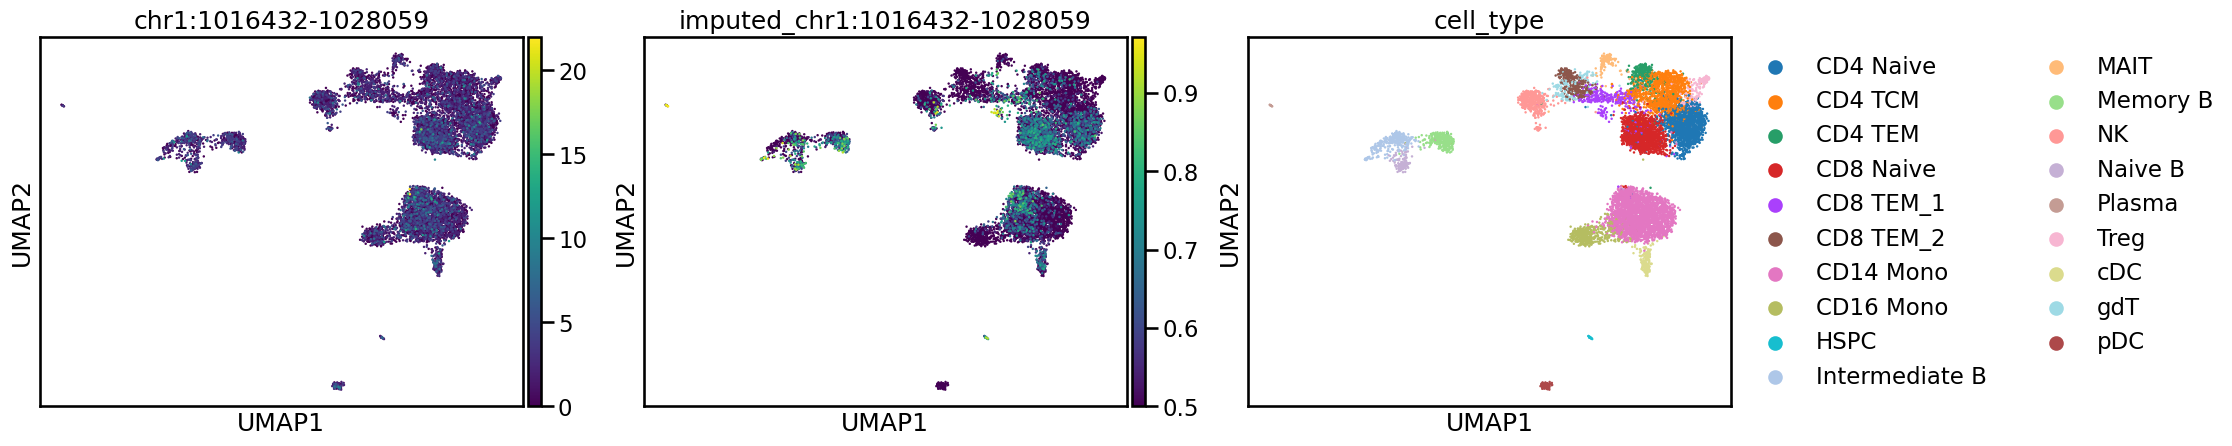

In [ ]:
sc.pl.umap(atac_peak, color=['chr1:1016432-1028059','imputed_chr1:1016432-1028059', 'cell_type'])

In [ ]:
sc.pp.highly_variable_genes(atac_peak, n_top_genes=2000, flavor='seurat_v3')

In [ ]:
atac_peak[:,atac_peak.var['highly_variable']].var_names

Index(['chr1:994735-1006799', 'chr1:1016432-1028059', 'chr1:1115011-1118473',
       'chr1:1342948-1350181', 'chr1:1397299-1403467', 'chr1:1570732-1575919',
       'chr1:1905851-1911844', 'chr1:1914190-1923960', 'chr1:2132143-2136521',
       'chr1:2310133-2323734',
       ...
       'chrX:54042470-54045488', 'chrX:103684787-103688366',
       'chrX:123959199-123964813', 'chrX:129776304-129786940',
       'chrX:135519863-135523480', 'chrX:153722626-153727950',
       'chrX:154396934-154403466', 'chrX:154546042-154548585',
       'GL000219.1:98653-100747', 'KI270713.1:20444-22615'],
      dtype='object', name='peaks', length=2000)

In [ ]:
adata_integrated.write_h5ad(r"D:\Scunpair_Project\Dataset\scRNA+scATAC 10x-Multiome-Pbmc10k\coembed.h5ad", compression='gzip')

In [ ]:
adata = sc.read_h5ad(r"D:\Scunpair_Project\Dataset\scRNA+scATAC 10x-Multiome-Pbmc10k\coembed.h5ad")

c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
adata

AnnData object with n_obs × n_vars = 19262 × 10
    obs: 'domain', 'protocol', 'dataset', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_ATAC', 'nFeature_ATAC', 'nCount_SCT', 'nFeature_SCT', 'SCT.weight', 'ATAC.weight', 'wsnn_res.0.8', 'seurat_clusters', 'sub.cluster', 'cell_type', 'modality', 'cluster_0.2', 'cluster_0.4', 'cluster_0.6', 'cluster_0.8', 'cluster_1.0', 'cluster_1.2', 'cluster_1.4', 'cluster_1.6', 'cluster_1.8', 'cluster_2.0', 'cluster', 'silhouette_temp'
    uns: 'cell_type_colors', 'cluster_0.2', 'cluster_0.4', 'cluster_0.6', 'cluster_0.8', 'cluster_1.0', 'cluster_1.2', 'cluster_1.4', 'cluster_1.6', 'cluster_1.8', 'cluster_2.0', 'modality_colors', 'neighbors', 'umap'
    obsm: 'X_emb', 'X_umap'
    obsp: 'connectivities', 'distances'